# Attitude Propagation Demo

This notebook demonstrates the attitude propagation capabilities of the
`src.dynamics.attitude_propagator` module. We cover:

1. **Principal axis mode**: Constant angular velocity rotation (closed-form solution)
2. **Tumbling mode**: Evolving angular velocity using Euler dynamics
3. **Integration with LCAS forward model**: Using propagated attitudes for lightcurve generation
4. **Visualization**: Quaternion and angular velocity evolution over time

## Key Concepts

- **Quaternions**: We use scalar-first convention `(w, x, y, z)` throughout
- **Body frame**: Angular velocity is expressed in the satellite's body-fixed frame
- **Principal axis rotation**: Stable rotation about a fixed axis (e.g., spin-stabilized satellites)
- **Tumbling dynamics**: Free rotation governed by Euler's equations (e.g., space debris)

## Prerequisites

Ensure you have the LCAS project set up with dependencies installed.

---
## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Project Root
if '__file__' in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent
else:
    PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.dynamics import (
    propagate_attitude,
    propagate_principal_axis,
    propagate_euler,
)

print(f"Project root: {PROJECT_ROOT}")
print("Imports successful!")

Project root: /home/girish/projects/lcas_v1.0
Imports successful!


---
## 1. Principal Axis Mode Propagation

In principal axis mode, we assume the satellite rotates at constant angular
velocity about a fixed axis in body frame. This is a valid assumption when:

- The satellite is spin-stabilized
- External torques are negligible
- The rotation is about a principal axis of inertia

The solution is computed in closed form:
$$q(t) = q_0 \cdot \exp\left(\frac{1}{2} \boldsymbol{\omega} \, t\right)$$

where the quaternion exponential represents the rotation about the angular
velocity axis.

In [2]:
# Define initial conditions
# Initial quaternion: identity (no rotation from reference)
q0 = np.array([1.0, 0.0, 0.0, 0.0])  # (w, x, y, z)

# Angular velocity: 10 deg/s about the Z-axis
omega_deg_s = 10.0  # degrees per second
omega_rad_s = np.deg2rad(omega_deg_s)
omega = np.array([0.0, 0.0, omega_rad_s])  # rad/s, body frame

# Time array: 0 to 60 seconds
times = np.linspace(0, 60, 601)  # 0.1 second steps

print("Initial conditions:")
print(f"  q0 = {q0}")
print(f"  omega = {omega} rad/s ({omega_deg_s} deg/s about Z)")
print(f"  Time span: {times[0]} to {times[-1]} seconds ({len(times)} points)")

Initial conditions:
  q0 = [1. 0. 0. 0.]
  omega = [0.         0.         0.17453293] rad/s (10.0 deg/s about Z)
  Time span: 0.0 to 60.0 seconds (601 points)


In [3]:
# Propagate attitude using principal axis mode
quaternions_principal, omega_history_principal = propagate_attitude(
    q0=q0,
    omega0=omega,
    times=times,
    mode="principal_axis",
)

print(f"\nPropagation results:")
print(f"  Quaternions shape: {quaternions_principal.shape}")
print(f"  Omega history shape: {omega_history_principal.shape}")
print(f"\n  First quaternion: {quaternions_principal[0]}")
print(f"  Last quaternion: {quaternions_principal[-1]}")

# Verify quaternion normalization
norms = np.linalg.norm(quaternions_principal, axis=1)
print(f"\n  Quaternion norm range: [{norms.min():.10f}, {norms.max():.10f}]")
print(f"  (should be 1.0)")


Propagation results:
  Quaternions shape: (601, 4)
  Omega history shape: (601, 3)

  First quaternion: [1. 0. 0. 0.]
  Last quaternion: [ 0.5        0.         0.        -0.8660254]

  Quaternion norm range: [1.0000000000, 1.0000000000]
  (should be 1.0)


In [4]:
# Verify the rotation angle progression
# For a Z-axis rotation, angle = 2 * arccos(w)
# After 60 seconds at 10 deg/s, total rotation = 600 degrees = 240 degrees (mod 360)
# In radians: 240 deg = 4*pi/3 rad, so cos(theta/2) = cos(2*pi/3) = -0.5

angles_from_w = 2 * np.arccos(np.clip(quaternions_principal[:, 0], -1, 1))
angles_deg = np.rad2deg(angles_from_w)

print("\nRotation angle verification:")
print(f"  Expected after 60s: {omega_deg_s * 60} deg (mod 360) = 240 deg")
print(f"  Computed final angle: {angles_deg[-1]:.2f} deg")


Rotation angle verification:
  Expected after 60s: 600.0 deg (mod 360) = 240 deg
  Computed final angle: 120.00 deg


---
## 2. Visualizing Principal Axis Rotation

Let's visualize the quaternion components and rotation angle over time.

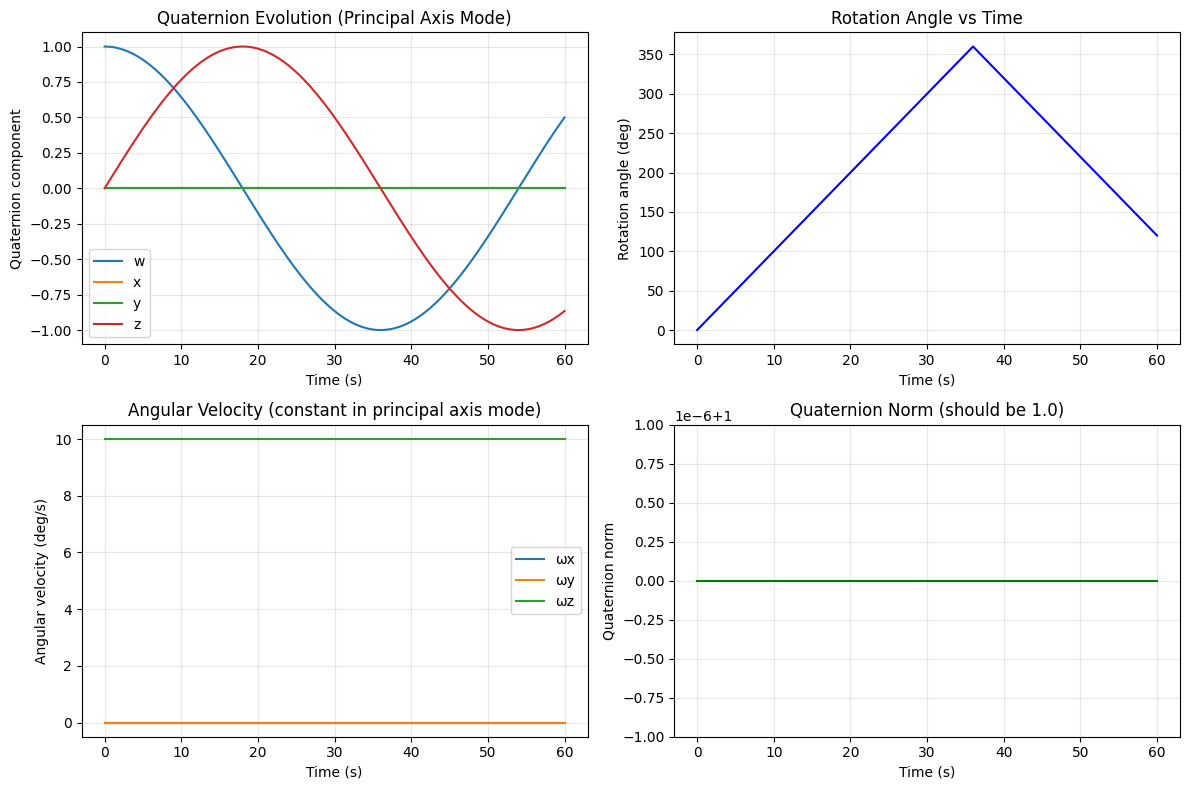

Figure saved to data/results/attitude_propagation_principal.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Quaternion components
ax1 = axes[0, 0]
ax1.plot(times, quaternions_principal[:, 0], label='w', linewidth=1.5)
ax1.plot(times, quaternions_principal[:, 1], label='x', linewidth=1.5)
ax1.plot(times, quaternions_principal[:, 2], label='y', linewidth=1.5)
ax1.plot(times, quaternions_principal[:, 3], label='z', linewidth=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Quaternion component')
ax1.set_title('Quaternion Evolution (Principal Axis Mode)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Rotation angle
ax2 = axes[0, 1]
ax2.plot(times, angles_deg, 'b-', linewidth=1.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Rotation angle (deg)')
ax2.set_title('Rotation Angle vs Time')
ax2.grid(True, alpha=0.3)

# Angular velocity (constant for principal axis)
ax3 = axes[1, 0]
ax3.plot(times, np.rad2deg(omega_history_principal[:, 0]), label='ωx', linewidth=1.5)
ax3.plot(times, np.rad2deg(omega_history_principal[:, 1]), label='ωy', linewidth=1.5)
ax3.plot(times, np.rad2deg(omega_history_principal[:, 2]), label='ωz', linewidth=1.5)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Angular velocity (deg/s)')
ax3.set_title('Angular Velocity (constant in principal axis mode)')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# Quaternion norm (should be 1.0)
ax4 = axes[1, 1]
ax4.plot(times, norms, 'g-', linewidth=1.5)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Quaternion norm')
ax4.set_title('Quaternion Norm (should be 1.0)')
ax4.set_ylim([0.999999, 1.000001])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'attitude_propagation_principal.png', dpi=150)
plt.show()

print("Figure saved to data/results/attitude_propagation_principal.png")

---
## 3. Tumbling Mode Propagation (Euler Dynamics)

In tumbling mode, the angular velocity evolves according to Euler's equations
of motion for a torque-free rigid body:

$$I \cdot \dot{\boldsymbol{\omega}} = -\boldsymbol{\omega} \times (I \cdot \boldsymbol{\omega})$$

where $I$ is the inertia tensor. This produces complex tumbling motion when
the initial angular velocity is not aligned with a principal axis.

### Conservation Laws

For torque-free motion, two quantities are conserved:
- **Angular momentum magnitude**: $|L| = |I \cdot \omega|$
- **Rotational kinetic energy**: $T = \frac{1}{2} \omega^T I \omega$

We'll verify these are conserved during integration.

In [6]:
# Define an asymmetric inertia tensor (principal moments along axes)
# This represents a satellite with different moments about each axis
I1 = 1000.0  # kg*m^2 (smallest)
I2 = 2000.0  # kg*m^2 (intermediate)
I3 = 3000.0  # kg*m^2 (largest)

inertia_tensor = np.diag([I1, I2, I3])

print("Inertia tensor (diagonal - principal axes aligned with body frame):")
print(f"  I1 (x-axis): {I1} kg*m^2")
print(f"  I2 (y-axis): {I2} kg*m^2")
print(f"  I3 (z-axis): {I3} kg*m^2")

Inertia tensor (diagonal - principal axes aligned with body frame):
  I1 (x-axis): 1000.0 kg*m^2
  I2 (y-axis): 2000.0 kg*m^2
  I3 (z-axis): 3000.0 kg*m^2


In [7]:
# Initial conditions for tumbling
q0_tumble = np.array([1.0, 0.0, 0.0, 0.0])

# Angular velocity with components along multiple axes
# This will produce tumbling motion
omega0_tumble = np.array([0.1, 0.05, 0.02])  # rad/s

print(f"\nInitial conditions for tumbling:")
print(f"  q0 = {q0_tumble}")
print(f"  omega0 = {omega0_tumble} rad/s")
print(f"  omega0 magnitude = {np.linalg.norm(omega0_tumble):.4f} rad/s")

# Longer time span for tumbling
times_tumble = np.linspace(0, 300, 3001)  # 5 minutes, 0.1s steps


Initial conditions for tumbling:
  q0 = [1. 0. 0. 0.]
  omega0 = [0.1  0.05 0.02] rad/s
  omega0 magnitude = 0.1136 rad/s


In [8]:
# Propagate attitude using Euler dynamics
quaternions_tumble, omega_history_tumble = propagate_attitude(
    q0=q0_tumble,
    omega0=omega0_tumble,
    times=times_tumble,
    mode="tumbling",
    inertia_tensor=inertia_tensor,
)

print(f"\nTumbling propagation results:")
print(f"  Quaternions shape: {quaternions_tumble.shape}")
print(f"  Omega history shape: {omega_history_tumble.shape}")


Tumbling propagation results:
  Quaternions shape: (3001, 4)
  Omega history shape: (3001, 3)


In [9]:
# Verify conservation laws

# Angular momentum: L = I @ omega
L_history = np.array([inertia_tensor @ omega_history_tumble[i]
                      for i in range(len(times_tumble))])
L_magnitude = np.linalg.norm(L_history, axis=1)

# Kinetic energy: T = 0.5 * omega^T @ I @ omega
T_history = np.array([
    0.5 * omega_history_tumble[i] @ inertia_tensor @ omega_history_tumble[i]
    for i in range(len(times_tumble))
])

print("\nConservation law verification:")
print(f"  Angular momentum magnitude:")
print(f"    Initial: {L_magnitude[0]:.6f} kg*m^2/s")
print(f"    Final:   {L_magnitude[-1]:.6f} kg*m^2/s")
print(f"    Max deviation: {np.abs(L_magnitude - L_magnitude[0]).max():.2e}")

print(f"\n  Kinetic energy:")
print(f"    Initial: {T_history[0]:.6f} J")
print(f"    Final:   {T_history[-1]:.6f} J")
print(f"    Max deviation: {np.abs(T_history - T_history[0]).max():.2e}")


Conservation law verification:
  Angular momentum magnitude:
    Initial: 153.622915 kg*m^2/s
    Final:   153.622915 kg*m^2/s
    Max deviation: 3.29e-08

  Kinetic energy:
    Initial: 8.100000 J
    Final:   8.100000 J
    Max deviation: 2.61e-09


---
## 4. Visualizing Tumbling Dynamics

The tumbling motion shows characteristic polhode curves in the angular
velocity space and evolving angular momentum components.

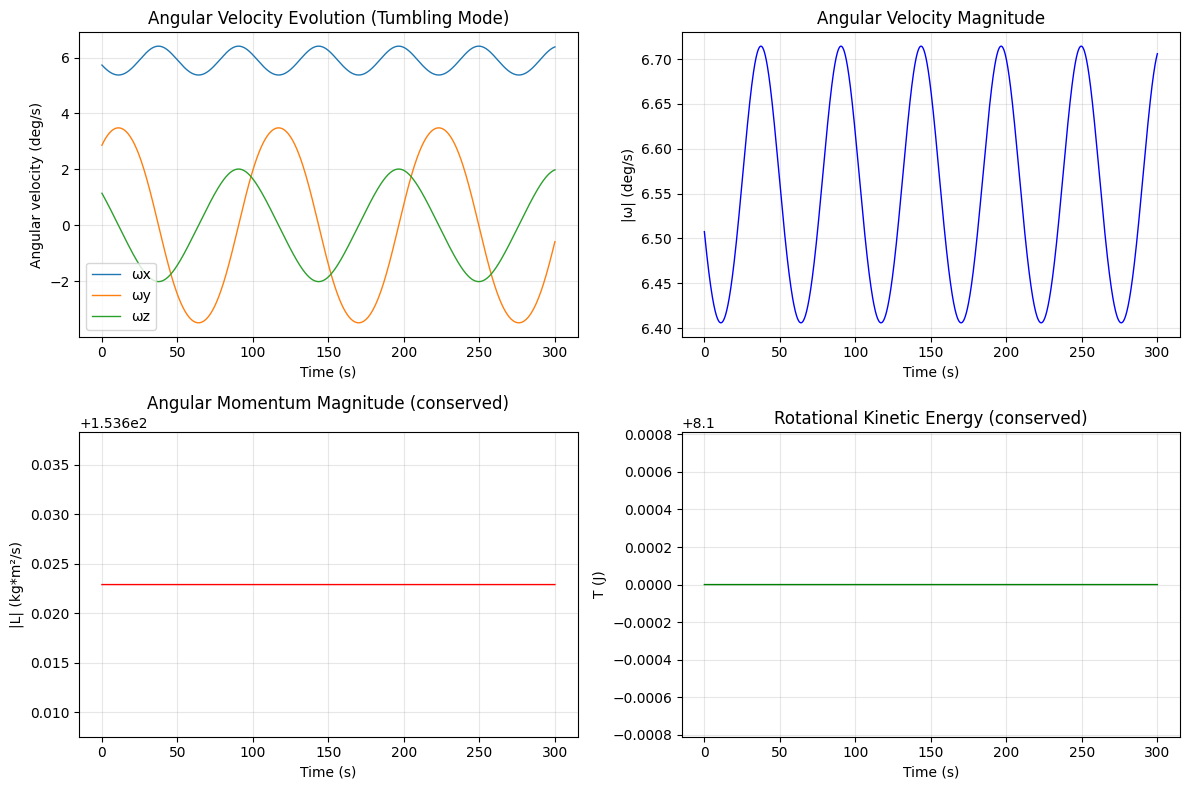

Figure saved to data/results/attitude_propagation_tumbling.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Angular velocity components
ax1 = axes[0, 0]
ax1.plot(times_tumble, np.rad2deg(omega_history_tumble[:, 0]), label='ωx', linewidth=1)
ax1.plot(times_tumble, np.rad2deg(omega_history_tumble[:, 1]), label='ωy', linewidth=1)
ax1.plot(times_tumble, np.rad2deg(omega_history_tumble[:, 2]), label='ωz', linewidth=1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Angular velocity (deg/s)')
ax1.set_title('Angular Velocity Evolution (Tumbling Mode)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Angular velocity magnitude
ax2 = axes[0, 1]
omega_mag = np.linalg.norm(omega_history_tumble, axis=1)
ax2.plot(times_tumble, np.rad2deg(omega_mag), 'b-', linewidth=1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('|ω| (deg/s)')
ax2.set_title('Angular Velocity Magnitude')
ax2.grid(True, alpha=0.3)

# Conservation: Angular momentum magnitude
ax3 = axes[1, 0]
ax3.plot(times_tumble, L_magnitude, 'r-', linewidth=1)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('|L| (kg*m²/s)')
ax3.set_title('Angular Momentum Magnitude (conserved)')
ax3.set_ylim([L_magnitude[0] * 0.9999, L_magnitude[0] * 1.0001])
ax3.grid(True, alpha=0.3)

# Conservation: Kinetic energy
ax4 = axes[1, 1]
ax4.plot(times_tumble, T_history, 'g-', linewidth=1)
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('T (J)')
ax4.set_title('Rotational Kinetic Energy (conserved)')
ax4.set_ylim([T_history[0] * 0.9999, T_history[0] * 1.0001])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'attitude_propagation_tumbling.png', dpi=150)
plt.show()

print("Figure saved to data/results/attitude_propagation_tumbling.png")

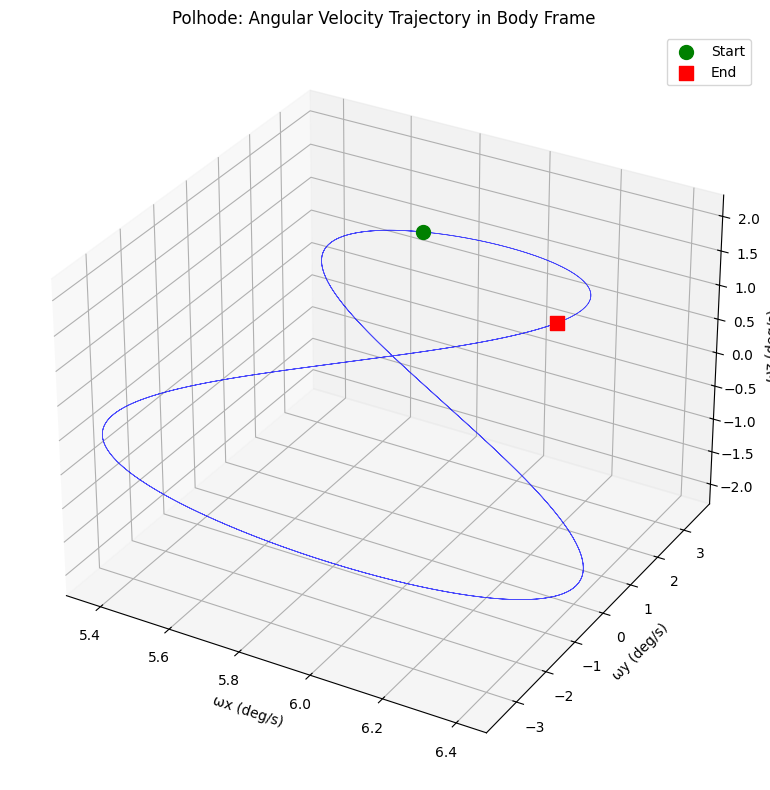

Figure saved to data/results/polhode_plot.png


In [11]:
# Polhode plot: angular velocity trajectory in body frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

omega_deg = np.rad2deg(omega_history_tumble)
ax.plot(omega_deg[:, 0], omega_deg[:, 1], omega_deg[:, 2],
        'b-', linewidth=0.5, alpha=0.7)
ax.scatter(omega_deg[0, 0], omega_deg[0, 1], omega_deg[0, 2],
           c='green', s=100, label='Start', marker='o')
ax.scatter(omega_deg[-1, 0], omega_deg[-1, 1], omega_deg[-1, 2],
           c='red', s=100, label='End', marker='s')

ax.set_xlabel('ωx (deg/s)')
ax.set_ylabel('ωy (deg/s)')
ax.set_zlabel('ωz (deg/s)')
ax.set_title('Polhode: Angular Velocity Trajectory in Body Frame')
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'polhode_plot.png', dpi=150)
plt.show()

print("Figure saved to data/results/polhode_plot.png")

---
## 5. Quaternion Evolution in Tumbling Mode

The quaternion also evolves in a complex manner during tumbling.

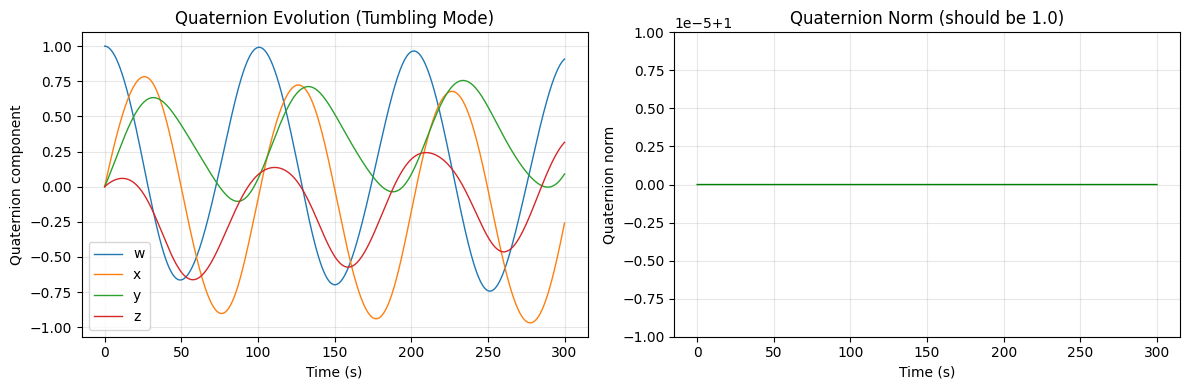

Figure saved to data/results/quaternion_tumbling.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Quaternion components
ax1 = axes[0]
ax1.plot(times_tumble, quaternions_tumble[:, 0], label='w', linewidth=1)
ax1.plot(times_tumble, quaternions_tumble[:, 1], label='x', linewidth=1)
ax1.plot(times_tumble, quaternions_tumble[:, 2], label='y', linewidth=1)
ax1.plot(times_tumble, quaternions_tumble[:, 3], label='z', linewidth=1)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Quaternion component')
ax1.set_title('Quaternion Evolution (Tumbling Mode)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Quaternion norm
ax2 = axes[1]
norms_tumble = np.linalg.norm(quaternions_tumble, axis=1)
ax2.plot(times_tumble, norms_tumble, 'g-', linewidth=1)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Quaternion norm')
ax2.set_title('Quaternion Norm (should be 1.0)')
ax2.set_ylim([0.99999, 1.00001])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'quaternion_tumbling.png', dpi=150)
plt.show()

print("Figure saved to data/results/quaternion_tumbling.png")

---
## 6. Using Propagator Output with LCAS Forward Model

The attitude propagator outputs can be directly used with the LCAS forward
model to generate lightcurves. The workflow is:

1. **Propagate attitude** to get quaternion history
2. **Convert J2000 vectors to body frame** using quaternions
3. **Call generate_lightcurves** with body-frame sun/observer vectors

Here we demonstrate the coordinate transformation step.

In [13]:
def quaternion_to_rotation_matrix(q):
    """
    Convert quaternion to rotation matrix (J2000 to body frame).

    Parameters
    ----------
    q : ndarray, shape (4,)
        Quaternion (w, x, y, z) - scalar first convention.

    Returns
    -------
    ndarray, shape (3, 3)
        Rotation matrix that transforms vectors FROM J2000 TO body frame.
    """
    w, x, y, z = q
    return np.array([
        [1 - 2*y*y - 2*z*z, 2*x*y - 2*w*z, 2*x*z + 2*w*y],
        [2*x*y + 2*w*z, 1 - 2*x*x - 2*z*z, 2*y*z - 2*w*x],
        [2*x*z - 2*w*y, 2*y*z + 2*w*x, 1 - 2*x*x - 2*y*y],
    ])


def compute_body_frame_vectors(quaternions, sun_j2000, observer_j2000, satellite_j2000):
    """
    Transform sun and observer vectors from J2000 to body frame.

    Parameters
    ----------
    quaternions : ndarray, shape (N, 4)
        Attitude quaternions at each time step.
    sun_j2000 : ndarray, shape (N, 3)
        Sun positions in J2000 frame.
    observer_j2000 : ndarray, shape (N, 3)
        Observer positions in J2000 frame.
    satellite_j2000 : ndarray, shape (N, 3)
        Satellite positions in J2000 frame.

    Returns
    -------
    k1_vectors : ndarray, shape (N, 3)
        Sun direction vectors in body frame (normalized).
    k2_vectors : ndarray, shape (N, 3)
        Observer direction vectors in body frame (normalized).
    """
    n_obs = len(quaternions)
    k1_vectors = np.zeros((n_obs, 3))
    k2_vectors = np.zeros((n_obs, 3))

    for i in range(n_obs):
        R = quaternion_to_rotation_matrix(quaternions[i])

        # Sun direction: from satellite to sun, in body frame
        sun_vec_j2000 = sun_j2000[i] - satellite_j2000[i]
        sun_vec_body = R @ sun_vec_j2000
        k1_vectors[i] = sun_vec_body / np.linalg.norm(sun_vec_body)

        # Observer direction: from satellite to observer, in body frame
        obs_vec_j2000 = observer_j2000[i] - satellite_j2000[i]
        obs_vec_body = R @ obs_vec_j2000
        k2_vectors[i] = obs_vec_body / np.linalg.norm(obs_vec_body)

    return k1_vectors, k2_vectors

In [ ]:
# Demonstration: simulate simple geometry
# Satellite at origin, Sun along +X in J2000, Observer along +Z in J2000

n_demo = 100
times_demo = np.linspace(0, 36, n_demo)  # One full rotation at 10 deg/s

# Simple geometry (all constant in J2000)
sun_j2000 = np.tile([150e6, 0, 0], (n_demo, 1))  # Sun along +X (km)
observer_j2000 = np.tile([0, 0, 40000], (n_demo, 1))  # Observer along +Z (km)
satellite_j2000 = np.zeros((n_demo, 3))  # Satellite at origin

# Propagate attitude: rotation about Z at 10 deg/s
q0_demo = np.array([1.0, 0.0, 0.0, 0.0])
omega_demo = np.array([0.0, 0.0, np.deg2rad(10)])

quaternions_demo, _ = propagate_attitude(
    q0=q0_demo, omega0=omega_demo, times=times_demo, mode="principal_axis"
)

# Compute body-frame vectors
k1_demo, k2_demo = compute_body_frame_vectors(
    quaternions_demo, sun_j2000, observer_j2000, satellite_j2000
)

print("Body-frame vector demonstration:")
print(f"  Time span: {times_demo[0]} to {times_demo[-1]} s (one rotation)")
print(f"\n  At t=0: Sun in body frame = {k1_demo[0]}")
print(f"          Observer in body frame = {k2_demo[0]}")
print(f"\n  At t=18s (180 deg): Sun in body frame = {k1_demo[50]}")
print(f"                      Observer in body frame = {k2_demo[50]}")

In [ ]:
# Visualize how k1 (sun direction) rotates in body frame
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# k1 (sun direction) components
ax1 = axes[0]
ax1.plot(times_demo, k1_demo[:, 0], label='k1_x', linewidth=1.5)
ax1.plot(times_demo, k1_demo[:, 1], label='k1_y', linewidth=1.5)
ax1.plot(times_demo, k1_demo[:, 2], label='k1_z', linewidth=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Component')
ax1.set_title('Sun Direction (k1) in Body Frame')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# k2 (observer direction) components
ax2 = axes[1]
ax2.plot(times_demo, k2_demo[:, 0], label='k2_x', linewidth=1.5)
ax2.plot(times_demo, k2_demo[:, 1], label='k2_y', linewidth=1.5)
ax2.plot(times_demo, k2_demo[:, 2], label='k2_z', linewidth=1.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Component')
ax2.set_title('Observer Direction (k2) in Body Frame')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'body_frame_vectors.png', dpi=150)
plt.show()

print("Figure saved to data/results/body_frame_vectors.png")

---
## 7. Comparison: Principal Axis vs Tumbling

Let's compare the two modes with similar initial conditions to highlight
the difference in behavior.

In [ ]:
# Same initial quaternion and angular velocity for both
q0_compare = np.array([1.0, 0.0, 0.0, 0.0])
omega0_compare = np.array([0.05, 0.05, 0.1])  # rad/s

# Define inertia for tumbling (same as before)
inertia_compare = np.diag([1000.0, 2000.0, 3000.0])

# Time span
times_compare = np.linspace(0, 120, 1201)

# Propagate both modes
q_principal, omega_principal = propagate_attitude(
    q0=q0_compare, omega0=omega0_compare, times=times_compare, mode="principal_axis"
)

q_tumbling, omega_tumbling = propagate_attitude(
    q0=q0_compare, omega0=omega0_compare, times=times_compare,
    mode="tumbling", inertia_tensor=inertia_compare
)

In [ ]:
# Compare angular velocity evolution
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

components = ['ωx', 'ωy', 'ωz']
for i in range(3):
    # Principal axis mode (top row)
    axes[0, i].plot(times_compare, np.rad2deg(omega_principal[:, i]), 'b-', linewidth=1)
    axes[0, i].set_xlabel('Time (s)')
    axes[0, i].set_ylabel(f'{components[i]} (deg/s)')
    axes[0, i].set_title(f'Principal Axis: {components[i]}')
    axes[0, i].grid(True, alpha=0.3)

    # Tumbling mode (bottom row)
    axes[1, i].plot(times_compare, np.rad2deg(omega_tumbling[:, i]), 'r-', linewidth=1)
    axes[1, i].set_xlabel('Time (s)')
    axes[1, i].set_ylabel(f'{components[i]} (deg/s)')
    axes[1, i].set_title(f'Tumbling: {components[i]}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'results' / 'mode_comparison.png', dpi=150)
plt.show()

print("Figure saved to data/results/mode_comparison.png")
print("\nKey observation:")
print("  - Principal axis mode: ω is CONSTANT (by assumption)")
print("  - Tumbling mode: ω components EVOLVE due to Euler dynamics")

---
## Summary

This notebook demonstrated the attitude propagation module with two modes:

### Principal Axis Mode
- **Use case**: Spin-stabilized satellites, simple rotations
- **Assumption**: Constant angular velocity in body frame
- **Solution**: Closed-form quaternion exponential
- **Efficiency**: Very fast, no numerical integration

### Tumbling Mode
- **Use case**: Space debris, tumbling satellites
- **Physics**: Euler's equations + quaternion kinematics
- **Solution**: Numerical integration (DOP853)
- **Conservation**: Angular momentum and kinetic energy preserved

### Integration with LCAS
The propagator output (quaternions) can be used to transform J2000 vectors
to body frame for lightcurve generation:

```python
# 1. Propagate attitude
quaternions, omega_history = propagate_attitude(q0, omega0, times, mode)

# 2. Transform vectors to body frame
k1_vectors, k2_vectors = compute_body_frame_vectors(
    quaternions, sun_j2000, observer_j2000, satellite_j2000
)

# 3. Generate lightcurve (using LCAS forward model)
magnitudes, ... = generate_lightcurves(
    facet_lit_status_dict, k1_vectors, k2_vectors, ...
)
```

The `ObjectiveFunction` class in `src.inversion.objective_function` implements
this pipeline for lightcurve inversion optimization.